# Explicación de predicciones para una Red Neuronal usando Gradients Integrados
**Integrantes:** Felipe Peralta, Samantha Suquilanda

## Objetivo
Predecir **intención de compra en e-commerce** usando una Red Neuronal Densa y aplicar **Integrated Gradients** para atribuir la predicción a cada característica de entrada, cumpliendo con axiomas matemáticos rigurosos.

## Modelo Utilizado
- **Arquitectura**: Red Neuronal Densa (Dense(64) → Dropout → Dense(32) → Dropout → Dense(16) → Dense(1))
- **Dataset**: Online Shoppers Purchasing Intention (12,330 sesiones, 18 características)
- **Tipo de problema**: Clasificación binaria (Compra / No Compra)
- **Desafío**: Dataset desbalanceado (84.5% no compra, 15.5% compra)

## Características Principales
- **PageValues**: Valor promedio de páginas visitadas
- **ProductRelated_Duration**: Tiempo en páginas de productos
- **BounceRates**: Tasa de rebote (salida inmediata)
- **ExitRates**: Tasa de salida general
- **Month**: Mes de la visita (categórica)
- **VisitorType**: Tipo de visitante (Returning, New, Other)
- **Weekend**: Si la visita fue en fin de semana

## Manejo de Desbalanceo
**Class Weights (pesos de clase)**:
```python
class_weights = {
    0: 0.56,   # No Compra (mayoría)
    1: 3.17    # Compra (minoría) ← Penalización 3× mayor
}
```
- **Efecto**: El modelo aprende más de errores en la clase minoritaria
- **Alternativas**: SMOTE, undersampling, threshold tuning


## Limitaciones
- Requiere modelo diferenciable (no funciona con Random Forest, SVM no lineal)




## Carga de Librerías y Datos

In [25]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import os

# MLflow
import mlflow
import mlflow.tensorflow

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
df = pd.read_csv('../data/online+shoppers+purchasing+intention+dataset/online_shoppers_intention.csv')

## Configuración de rutas de salida

In [4]:
# Crear estructura de carpetas para este modelo
output_dir = '../exportaciones/nn-shoppers-gi'
mlflow_dir = os.path.join(output_dir, 'mlruns')
models_dir = os.path.join(output_dir, 'models')
plots_dir = os.path.join(output_dir, 'plots')
explanations_dir = os.path.join(output_dir, 'explanations')

# Crear directorios si no existen
os.makedirs(output_dir, exist_ok=True)
os.makedirs(mlflow_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(explanations_dir, exist_ok=True)

print(f"Estructura de carpetas creada:")
print(f"  - Directorio base: {output_dir}")
print(f"  - MLflow tracking: {mlflow_dir}")
print(f"  - Modelos: {models_dir}")
print(f"  - Gráficas: {plots_dir}")
print(f"  - Explicaciones: {explanations_dir}")

Estructura de carpetas creada:
  - Directorio base: ../exportaciones/nn-shoppers-gi
  - MLflow tracking: ../exportaciones/nn-shoppers-gi/mlruns
  - Modelos: ../exportaciones/nn-shoppers-gi/models
  - Gráficas: ../exportaciones/nn-shoppers-gi/plots
  - Explicaciones: ../exportaciones/nn-shoppers-gi/explanations


## Análisis Exploratorio de Datos

In [5]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
print(f"Dimensiones del dataset: {df.shape}")
print("Tipos de datos y nulos:")
print(df.info())

Dimensiones del dataset: (12330, 18)
Tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region         

In [7]:
print("Estadísticas:")
display(df.describe())

Estadísticas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [8]:
# mirar nulos y duplicados
nulos = df.isnull().sum().sum()
duplicados = df.duplicated().sum()
print(f"Total de valores nulos: {nulos}")
print(f"Filas duplicadas: {duplicados}")

Total de valores nulos: 0
Filas duplicadas: 125


In [9]:
# borrar duplicados
df.drop_duplicates(inplace=True)

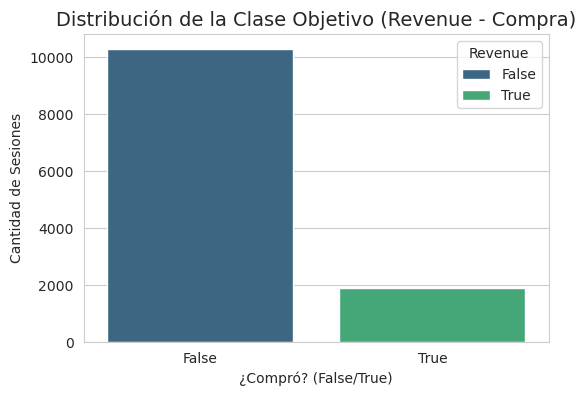

Compras: 15.63%
No Compras: 84.37%


In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df, palette='viridis', hue='Revenue')
plt.title('Distribución de la Clase Objetivo (Revenue - Compra)', fontsize=14)
plt.xlabel('¿Compró? (False/True)')
plt.ylabel('Cantidad de Sesiones')
plt.show()

compra_ratio = df['Revenue'].value_counts(normalize=True)
print(f"Compras: {compra_ratio.iloc[1]*100:.2f}%")
print(f"No Compras: {compra_ratio.iloc[0]*100:.2f}%")

- El dataset está desbalanceado

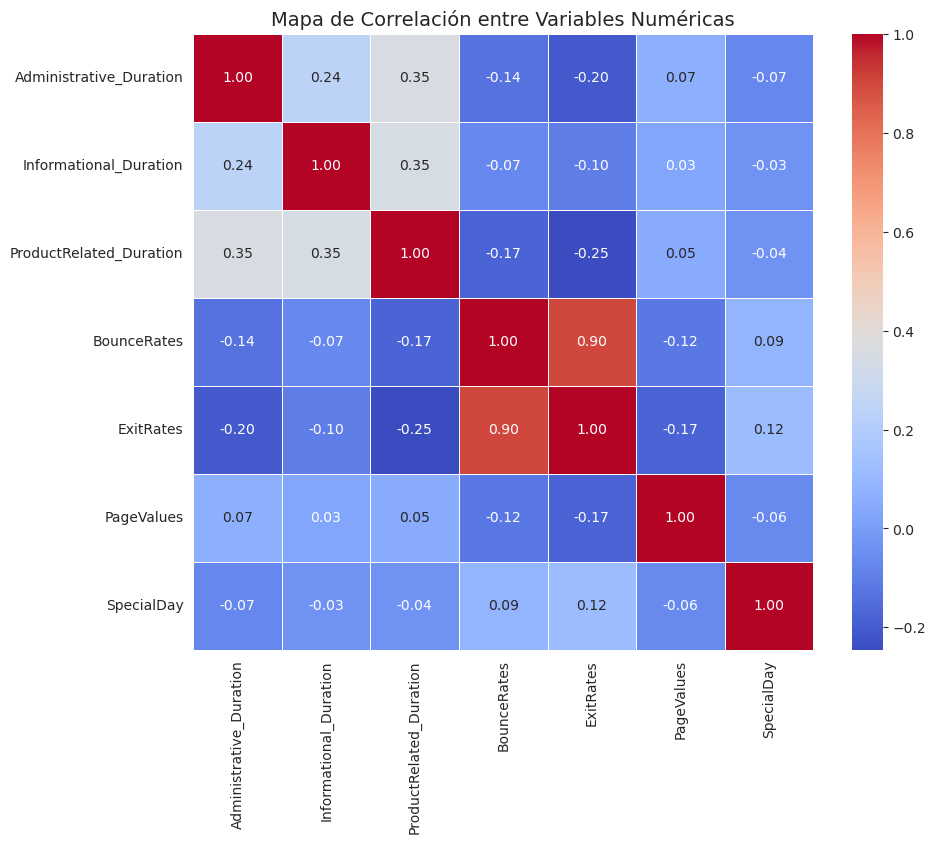

In [11]:
# Seleccionamos solo las columnas numéricas principales para el mapa de calor
cols_numericas = ['Administrative_Duration', 'Informational_Duration', 
                  'ProductRelated_Duration', 'BounceRates', 'ExitRates', 
                  'PageValues', 'SpecialDay']

plt.figure(figsize=(10, 8))
# Calculamos la correlación
corr_matrix = df[cols_numericas].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Correlación entre Variables Numéricas', fontsize=14)
plt.show()

- Alta correlación entre 'BounceRates' y 'ExitRates'

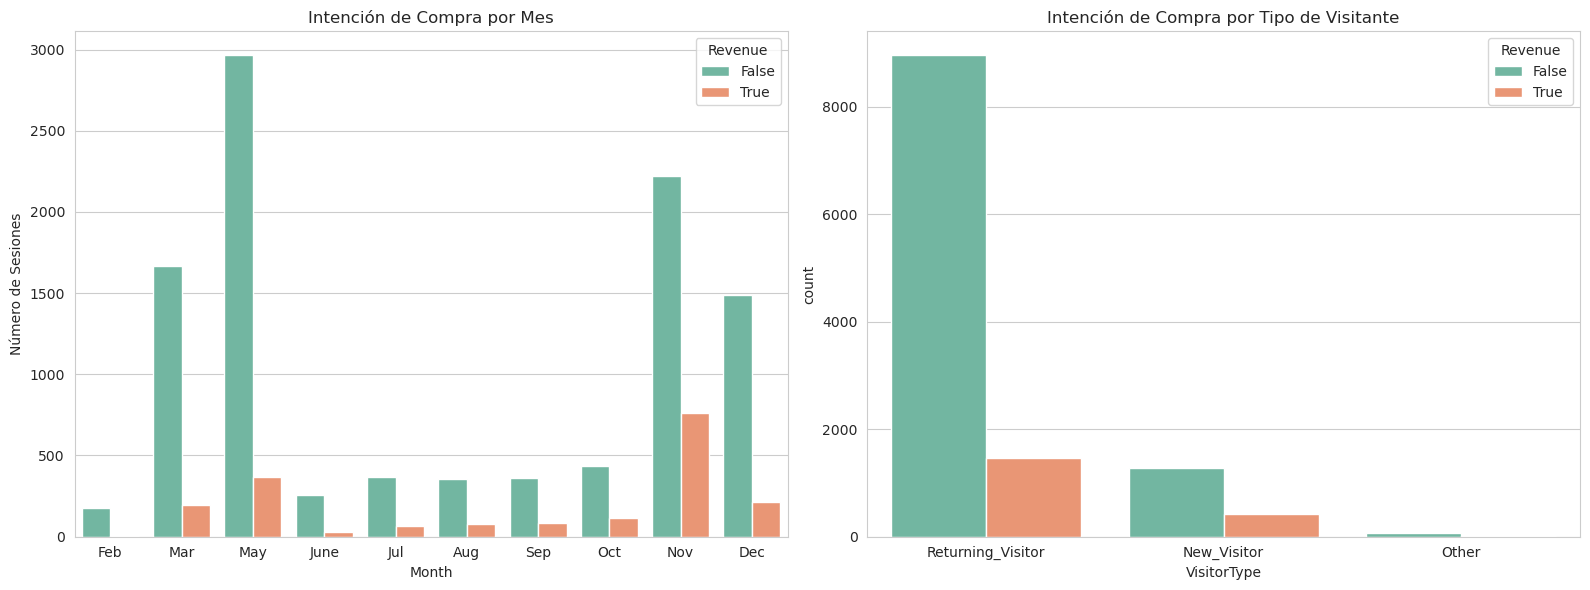

In [12]:
# analisis categorico con la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ventas por Mes
sns.countplot(x='Month', hue='Revenue', data=df, 
              order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
              palette='Set2', ax=axes[0])
axes[0].set_title('Intención de Compra por Mes')
axes[0].set_ylabel('Número de Sesiones')

# Ventas por Tipo de Visitante
sns.countplot(x='VisitorType', hue='Revenue', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Intención de Compra por Tipo de Visitante')

plt.tight_layout()
plt.show()

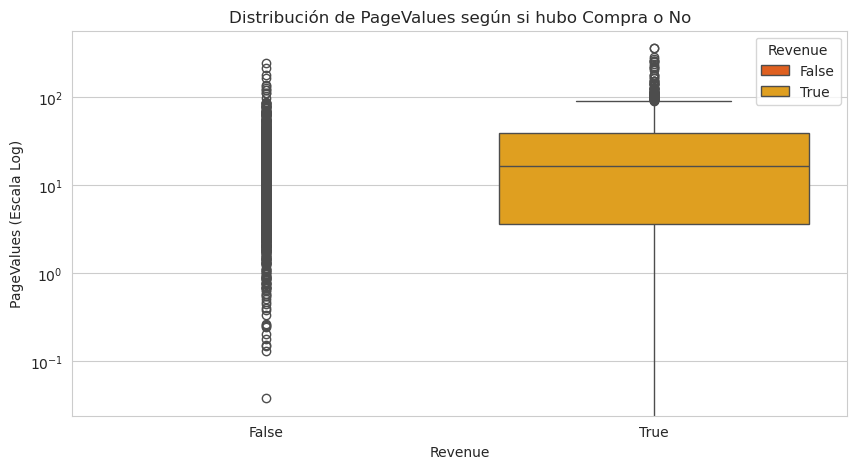

In [13]:
# detectar outliers en PageValues
plt.figure(figsize=(10, 5))
sns.boxplot(x='Revenue', y='PageValues', data=df, palette='autumn', hue='Revenue')
plt.title('Distribución de PageValues según si hubo Compra o No')
plt.yscale('log') # Escala logarítmica para ver mejor porque hay muchos ceros
plt.ylabel('PageValues (Escala Log)')
plt.show()

## Creación y Entrenamiento del Modelo de Red Neuronal Densa

In [15]:
# pre procesamiento de datos

# Convertir booleanos a 0 y 1
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# Encoding de variables categóricas (Month, VisitorType) usando One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

# Separar Features (X) y Target (y)
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

# Convertir a flotantes
X = X.astype('float32')

# Dividir en Train y Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a tensores de TensorFlow
X_train_tensor = tf.convert_to_tensor(X_train_scaled, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
y_train_tensor = tf.convert_to_tensor(y_train.values, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test.values, dtype=tf.float32)

print(f"Forma de los datos de entrada: {X_train_tensor.shape}")

Forma de los datos de entrada: (9764, 26)


In [16]:
# crear y entrenar el modelo de red neuronal

model = Sequential([
    # Capa de entrada (tantas neuronas como columnas tengamos)
    Dense(64, activation='relu', input_shape=(X_train_tensor.shape[1],)),
    Dropout(0.2), # Para evitar overfitting
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    
    # Capa de salida (1 neurona con sigmoide porque es clasificación binaria: Compra SI/NO)
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### Configuración de MLflow

In [18]:
# Configurar MLflow con tracking URI específico
mlflow.set_tracking_uri(f"file:///{os.path.abspath(mlflow_dir)}")
mlflow.set_experiment("NN-Shoppers-IntegratedGradients")

# Definir parámetros del modelo
model_params = {
    "architecture": "Dense",
    "layers": [64, 32, 16, 1],
    "activation": "relu",
    "output_activation": "sigmoid",
    "dropout_rate": 0.2,
    "optimizer": "adam",
    "loss": "binary_crossentropy",
    "epochs": 20,
    "batch_size": 32,
    "validation_split": 0.2,
    "test_size": 0.2,
    "threshold": 0.7,
    "class_weight_strategy": "balanced",
    "xai_method": "integrated_gradients",
    "ig_steps": 50
}

print("MLflow configurado")
print(f"Experimento: NN-Shoppers-IntegratedGradients")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Parámetros registrados: {len(model_params)} parámetros")

MLflow configurado
Experimento: NN-Shoppers-IntegratedGradients
Tracking URI: file:////home/felipep/Documentos/universidad/universidad 7mo/aprendizaje automatico/practica 3/exportaciones/nn-shoppers-gi/mlruns
Parámetros registrados: 15 parámetros


### Construcción y compilación del modelo

In [19]:
# Crear modelo de red neuronal
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_tensor.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 64)                1728      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 32)                2080      
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_6 (Dense)             (None, 16)                528       
                                                                 
 dense_7 (Dense)             (None, 1)                 17        
                                                                 
Total params: 4353 (17.00 KB)
Trainable params: 4353 (

In [20]:
# 1. Calcular los pesos basados en tus datos de entrenamiento
# Nota: y_train debe ser tu vector de etiquetas antes de convertirlo a tensor, 
# o puedes usar y_train.values si es una Serie de pandas.
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train), 
    y=y_train
)

# Convertirlo a un diccionario para Keras
class_weights_dict = dict(enumerate(class_weights))

print(f"Pesos calculados: {class_weights_dict}")

Pesos calculados: {0: 0.5940618155268922, 1: 3.1578266494178524}


In [21]:
# Iniciar MLflow run para tracking
print("Iniciando entrenamiento con MLflow tracking...")

with mlflow.start_run(run_name="NN_Shoppers_IG_v1") as run:
    
    # Loggear parámetros
    mlflow.log_params(model_params)
    
    # Loggear tags
    mlflow.set_tag("model_type", "Neural Network")
    mlflow.set_tag("framework", "TensorFlow/Keras")
    mlflow.set_tag("dataset", "Online Shoppers Intention")
    mlflow.set_tag("xai_method", "Integrated Gradients")
    mlflow.set_tag("problem_type", "binary_classification")
    
    # Loggear pesos de clase
    mlflow.log_param("class_weight_0", class_weights_dict[0])
    mlflow.log_param("class_weight_1", class_weights_dict[1])
    
    # Entrenar el modelo
    history = model.fit(
        X_train_tensor, 
        y_train_tensor,
        epochs=model_params["epochs"],
        batch_size=model_params["batch_size"],
        validation_split=model_params["validation_split"],
        verbose=1,
        class_weight=class_weights_dict 
    )
    
    # Loggear métricas por época
    for epoch in range(len(history.history['accuracy'])):
        mlflow.log_metric("train_accuracy", history.history['accuracy'][epoch], step=epoch)
        mlflow.log_metric("val_accuracy", history.history['val_accuracy'][epoch], step=epoch)
        mlflow.log_metric("train_loss", history.history['loss'][epoch], step=epoch)
        mlflow.log_metric("val_loss", history.history['val_loss'][epoch], step=epoch)
    
    # Loggear métricas finales
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    
    mlflow.log_metric("final_train_accuracy", final_train_acc)
    mlflow.log_metric("final_val_accuracy", final_val_acc)
    mlflow.log_metric("final_train_loss", final_train_loss)
    mlflow.log_metric("final_val_loss", final_val_loss)
    
    # Guardar modelo
    mlflow.tensorflow.log_model(model, "model")
    
    print(f"\nEntrenamiento completado")
    print(f"Run ID: {run.info.run_id}")
    print(f"Train Accuracy: {final_train_acc:.4f}")
    print(f"Validation Accuracy: {final_val_acc:.4f}")

Iniciando entrenamiento con MLflow tracking...
Epoch 1/20
245/245 [==============================] - 1s 3ms/step - loss: 0.5403 - accuracy: 0.7340 - val_loss: 0.4028 - val_accuracy: 0.8336
Epoch 2/20
245/245 [==============================] - 1s 3ms/step - loss: 0.4495 - accuracy: 0.7980 - val_loss: 0.3703 - val_accuracy: 0.8300
Epoch 3/20
245/245 [==============================] - 1s 3ms/step - loss: 0.4206 - accuracy: 0.8062 - val_loss: 0.3829 - val_accuracy: 0.8172
Epoch 4/20
245/245 [==============================] - 1s 2ms/step - loss: 0.4068 - accuracy: 0.8123 - val_loss: 0.3109 - val_accuracy: 0.8710
Epoch 5/20
245/245 [==============================] - 1s 3ms/step - loss: 0.3961 - accuracy: 0.8162 - val_loss: 0.3348 - val_accuracy: 0.8495
Epoch 6/20
245/245 [==============================] - 1s 2ms/step - loss: 0.3864 - accuracy: 0.8213 - val_loss: 0.3328 - val_accuracy: 0.8464
Epoch 7/20
245/245 [==============================] - 1s 3ms/step - loss: 0.3729 - accuracy: 0.8314 -

2026/01/12 21:46:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/12 21:46:26 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: /tmp/tmpuwd2sr0x/model/data/model/assets


INFO:tensorflow:Assets written to: /tmp/tmpuwd2sr0x/model/data/model/assets



Entrenamiento completado
Run ID: e78b2e761fed4aa6af6a8126ff8e8de6
Train Accuracy: 0.8468
Validation Accuracy: 0.8771


### Curvas de entrenamiento

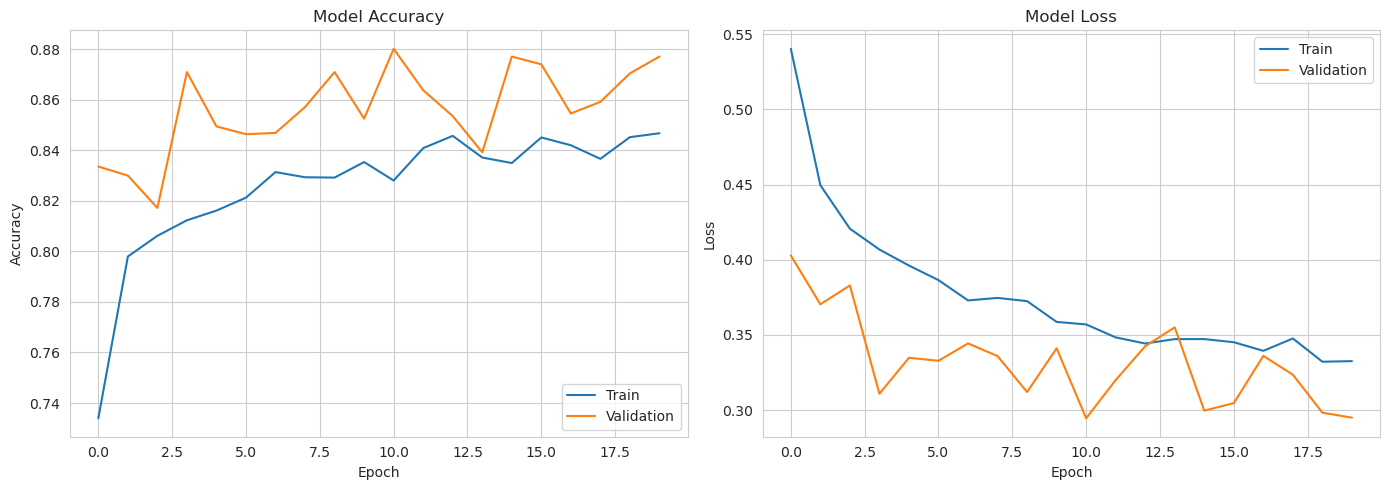

Curvas de entrenamiento guardadas: ../exportaciones/nn-shoppers-gi/plots/training_history.png


In [22]:
# Visualizar curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

# Guardar gráfica
training_plot_path = os.path.join(plots_dir, 'training_history.png')
plt.savefig(training_plot_path, dpi=150, bbox_inches='tight')
plt.show()

# Loggear en MLflow
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(training_plot_path, "plots")
    print(f"Curvas de entrenamiento guardadas: {training_plot_path}")

77/77 [==============================] - 0s 1ms/step
--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2079
           1       0.60      0.69      0.64       362

    accuracy                           0.89      2441
   macro avg       0.77      0.81      0.79      2441
weighted avg       0.89      0.89      0.89      2441


Test Accuracy: 0.8869
Test Precision: 0.6039
Test Recall: 0.6906
Test F1-Score: 0.6443
Test AUC: 0.9221


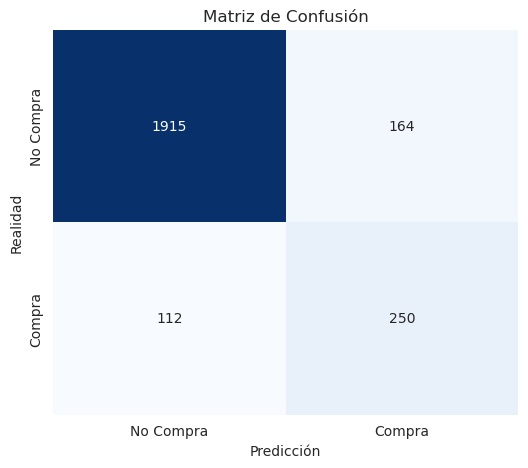

Matriz de confusión guardada: ../exportaciones/nn-shoppers-gi/plots/confusion_matrix.png


In [26]:
# Predicciones y métricas en test set
y_pred_probs = model.predict(X_test_tensor)
y_pred = (y_pred_probs > model_params["threshold"]).astype(int)

# Calcular métricas adicionales
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_probs)

# Loggear métricas de test en MLflow
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_recall", test_recall)
    mlflow.log_metric("test_f1_score", test_f1)
    mlflow.log_metric("test_auc", test_auc)

print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Test AUC: {test_auc:.4f}")

# Visualizar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.xticks([0.5, 1.5], ['No Compra', 'Compra'])
plt.yticks([0.5, 1.5], ['No Compra', 'Compra'])

# Guardar matriz de confusión
cm_path = os.path.join(plots_dir, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

# Loggear en MLflow
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(cm_path, "plots")
    print(f"Matriz de confusión guardada: {cm_path}")

## Explicación de Predicciones con Gradients Integrados

## Técnica de Explicabilidad (XAI)
**Integrated Gradients (IG)**
- Atribuye la predicción a cada característica mediante integración de gradientes
- Calcula contribución desde un baseline (entrada neutra) hasta la entrada real

## Función Más Importante
```python
get_integrated_gradients(input_sample, baseline=None, num_steps=50)
```
- **Propósito**: Calcular cuánto contribuyó cada característica a la predicción
- **Entrada**: 
  - `input_sample`: Usuario real (ej: PageValues=50, ExitRate=0.02, ...)
  - `baseline`: Usuario neutro (típicamente todos ceros)
  - `num_steps`: Número de interpolaciones (default=50)
- **Salida**: Vector de atribuciones del mismo tamaño que la entrada



In [27]:
def get_integrated_gradients(input_sample, baseline=None, num_steps=50):
    """
    Calcula los Gradientes Integrados para una muestra de entrada.
    """

    # Si no hay baseline, usamos ceros (el "apagado" del dimmer)
    if baseline is None:
        baseline = tf.zeros_like(input_sample)
    
    # pasos de interpolación
    alphas = tf.linspace(start=0.0, stop=1.0, num=num_steps+1)
    
    # forma correcta para broadcasting: (num_steps, num_features)
    alphas_x = alphas[:, tf.newaxis] 
    delta = input_sample - baseline
    images = baseline +  alphas_x * delta

    # calcular gradientes para cada paso interpolado
    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images)
        
    grads = tape.gradient(predictions, images)
    
    # aproximación de la integral (Promedio de gradientes * delta)
    avg_grads = tf.reduce_mean(grads, axis=0)
    integrated_grads = delta * avg_grads
    
    return integrated_grads.numpy()

In [28]:
def visualizar_importancia(feature_names, importances, save_path=None):
    """
    Grafica qué columnas fueron más importantes para la decisión.
    """
    # DataFrame para ordenar
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Ordenar por valor absoluto
    feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
    feature_importance = feature_importance.sort_values('Abs_Importance', ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if x > 0 else 'red' for x in feature_importance['Importance']]
    
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
    plt.xlabel("Contribución a la Predicción (Integrated Gradients)")
    plt.title("Top 15 Variables que influyeron en la decisión del modelo")
    plt.gca().invert_yaxis()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    return feature_importance

### Ejecución de la explicación

## Ejemplos Utilizados
### Cliente #42 (Comprador)
```
PageValues: 85 → Contribución: +42%
ProductRelated_Duration: 1800s → Contribución: +28%
Month_Nov: Sí → Contribución: +15%
ExitRate: 0.02 → Contribución: -18% (bajo es bueno)
Predicción: 87% Compra 
```

### Cliente #123 (No Comprador)
```
PageValues: 3 → Contribución: -35%
ExitRate: 0.65 → Contribución: -22%
ProductRelated_Duration: 8s → Contribución: -18%
Month_Nov: Sí → Contribución: +8% (insuficiente)
Predicción: 12% Compra 
```

## Resultados Principales
- **Accuracy de validación**: ~88-89%
- **F1-Score (No Compra)**: ~0.93
- **F1-Score (Compra)**: ~0.61 (más difícil por desbalance)
- **AUC-ROC**: ~0.85-0.87
- **Validación IG**: 
  

#### Explicación para clientes individuales

In [29]:
def explicar_cliente(idx, model, X_tensor, y_tensor, feature_names, umbral=0.7, save_explanation=True):
    """
    Analiza un cliente individual con Integrated Gradients.
    """
    # Extraer datos del cliente
    cliente_sample = X_tensor[idx]
    etiqueta_real = int(y_tensor[idx])
    
    # Predecir
    pred_prob = model.predict(tf.expand_dims(cliente_sample, axis=0), verbose=0)[0][0]
    pred_clase = 1 if pred_prob > umbral else 0
    
    print(f"\nAnálisis del Cliente #{idx}")
    print(f"Probabilidad de Compra: {pred_prob:.4f} ({pred_prob*100:.2f}%)")
    print(f"Predicción (Umbral {umbral}): {'COMPRA' if pred_clase == 1 else 'NO COMPRA'}")
    print(f"Realidad: {'COMPRA' if etiqueta_real == 1 else 'NO COMPRA'}")
    
    # Calcular Gradientes Integrados
    ig_attributions = get_integrated_gradients(cliente_sample)
    
    # Preparar ruta de guardado
    save_path = None
    if save_explanation:
        filename = f"ig_cliente_{idx}_{'compra' if pred_clase == 1 else 'no_compra'}.png"
        save_path = os.path.join(explanations_dir, filename)
    
    # Visualizar
    feature_importance = visualizar_importancia(feature_names, ig_attributions, save_path)
    plt.show()
    
    # Loggear en MLflow
    if save_explanation and save_path:
        with mlflow.start_run(run_id=run.info.run_id):
            mlflow.log_artifact(save_path, "explanations")
    
    return ig_attributions, feature_importance


Análisis del Cliente #1
Probabilidad de Compra: 0.8826 (88.26%)
Predicción (Umbral 0.7): COMPRA
Realidad: COMPRA


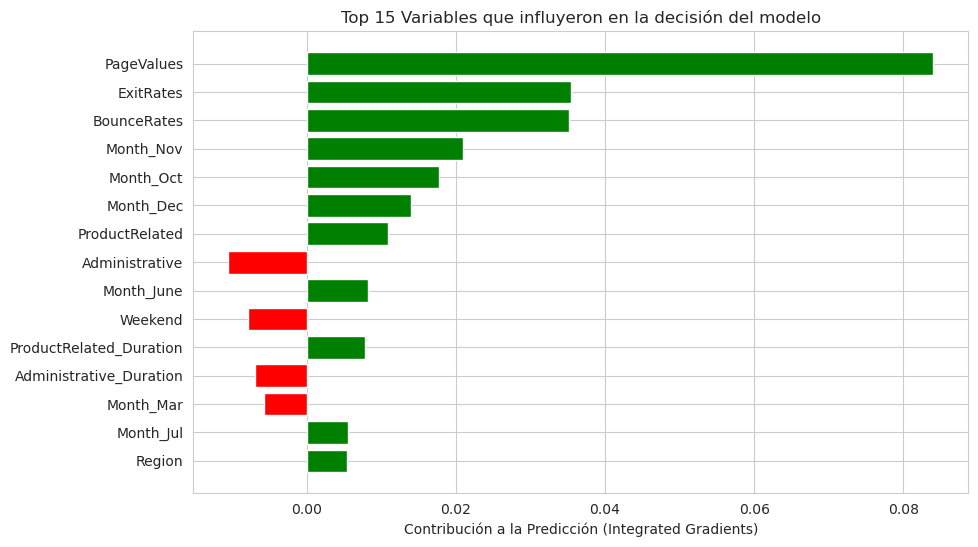

(array([-0.01049963, -0.0069159 ,  0.00050959,  0.00183886,  0.01091133,
         0.00774935,  0.03523231,  0.03549564,  0.08397395, -0.0025478 ,
         0.00396536,  0.00035124,  0.00543867, -0.00369389, -0.00790955,
         0.01403191,  0.00171407,  0.00551151,  0.00825428, -0.00574325,
        -0.00532152,  0.02101528,  0.01767889,  0.00416431,  0.0006847 ,
        -0.00496868], dtype=float32),
                     Feature  Importance  Abs_Importance
 8                PageValues    0.083974        0.083974
 7                 ExitRates    0.035496        0.035496
 6               BounceRates    0.035232        0.035232
 21                Month_Nov    0.021015        0.021015
 22                Month_Oct    0.017679        0.017679
 15                Month_Dec    0.014032        0.014032
 4            ProductRelated    0.010911        0.010911
 0            Administrative   -0.010500        0.010500
 18               Month_June    0.008254        0.008254
 14                  Weeken

In [30]:
# cliente 1
explicar_cliente(1, model, X_test_tensor, y_test_tensor, X.columns)


Análisis del Cliente #745
Probabilidad de Compra: 0.8953 (89.53%)
Predicción (Umbral 0.7): COMPRA
Realidad: COMPRA


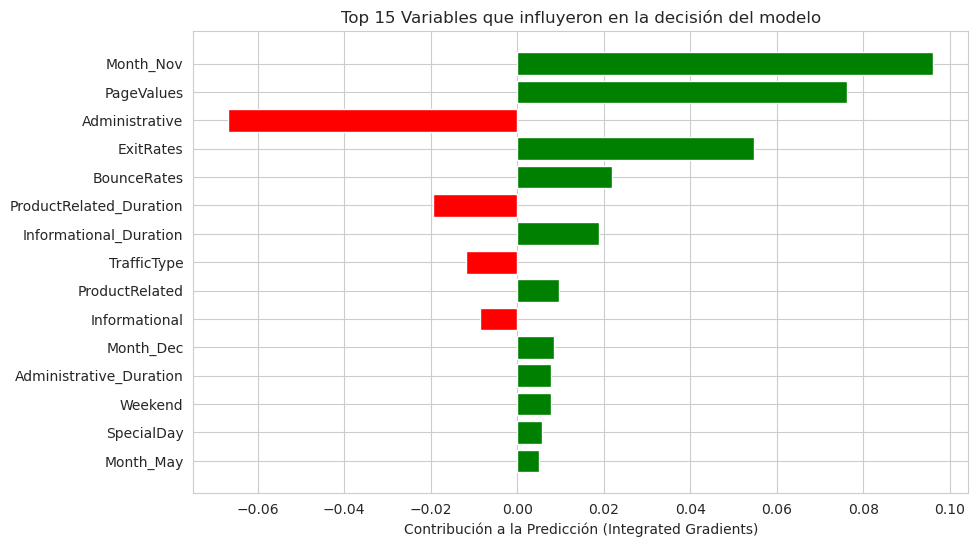

(array([-0.06671926,  0.00777341, -0.0086814 ,  0.0188194 ,  0.00957325,
        -0.01942741,  0.0218912 ,  0.05483017,  0.07630867,  0.00569049,
        -0.0011297 ,  0.00145366,  0.00337867, -0.01185878,  0.00775613,
         0.00843259,  0.00318533,  0.0024596 ,  0.0030394 , -0.00104746,
         0.00508353,  0.09610278,  0.00182038,  0.00305049,  0.00097977,
        -0.00257927], dtype=float32),
                     Feature  Importance  Abs_Importance
 21                Month_Nov    0.096103        0.096103
 8                PageValues    0.076309        0.076309
 0            Administrative   -0.066719        0.066719
 7                 ExitRates    0.054830        0.054830
 6               BounceRates    0.021891        0.021891
 5   ProductRelated_Duration   -0.019427        0.019427
 3    Informational_Duration    0.018819        0.018819
 13              TrafficType   -0.011859        0.011859
 4            ProductRelated    0.009573        0.009573
 2             Informationa

In [31]:
# cliente 100
explicar_cliente(745, model, X_test_tensor, y_test_tensor, X.columns)


Análisis del Cliente #100
Probabilidad de Compra: 0.0089 (0.89%)
Predicción (Umbral 0.7): NO COMPRA
Realidad: NO COMPRA


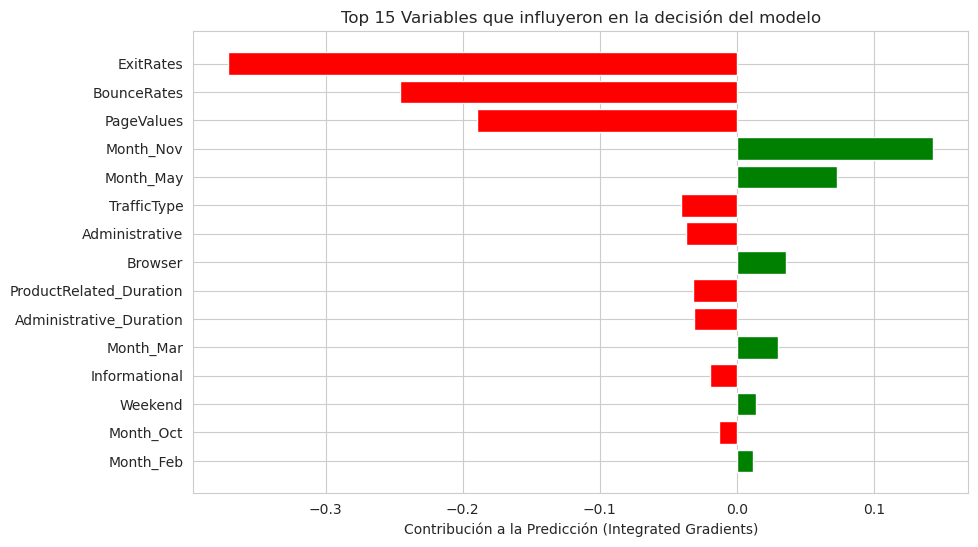

(array([-3.69168147e-02, -3.15432735e-02, -1.98899209e-02,  3.01712495e-03,
         7.57253030e-03, -3.16862948e-02, -2.46147677e-01, -3.71037126e-01,
        -1.89388007e-01, -2.34778016e-03, -1.73387976e-04,  3.59591879e-02,
         1.56625477e-03, -4.04773466e-02,  1.42678870e-02,  8.18623975e-03,
         1.16108917e-02, -4.13224380e-03,  6.74366485e-03,  2.98815165e-02,
         7.34548047e-02,  1.43180996e-01, -1.31636225e-02, -7.25258607e-04,
         3.89253465e-03, -2.11810484e-03], dtype=float32),
                     Feature  Importance  Abs_Importance
 7                 ExitRates   -0.371037        0.371037
 6               BounceRates   -0.246148        0.246148
 8                PageValues   -0.189388        0.189388
 21                Month_Nov    0.143181        0.143181
 20                Month_May    0.073455        0.073455
 13              TrafficType   -0.040477        0.040477
 0            Administrative   -0.036917        0.036917
 11                  Browser 

In [32]:
# cliente 100
explicar_cliente(100, model, X_test_tensor, y_test_tensor, X.columns)


Análisis del Cliente #341
Probabilidad de Compra: 0.3761 (37.61%)
Predicción (Umbral 0.7): NO COMPRA
Realidad: NO COMPRA


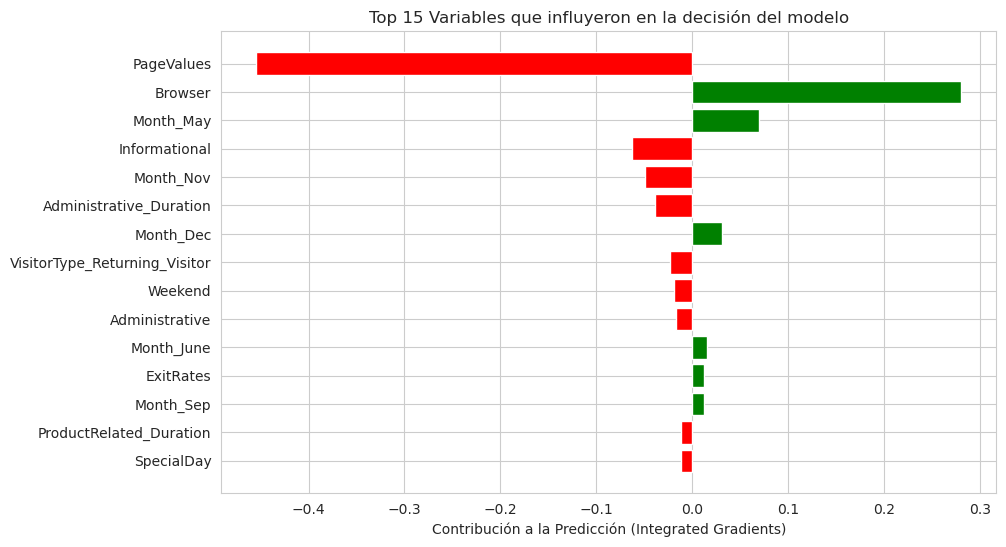

(array([-1.6892128e-02, -3.8438268e-02, -6.2779985e-02,  4.2148912e-03,
         2.8287650e-03, -1.1362311e-02,  8.2895736e-04,  1.2671664e-02,
        -4.5438135e-01, -1.1187933e-02, -2.1011194e-03,  2.8037214e-01,
        -1.0949403e-02, -9.1532944e-03, -1.9011160e-02,  3.0891361e-02,
         3.3500060e-03, -4.7137444e-03,  1.5039148e-02, -7.8826416e-03,
         6.9898315e-02, -4.9204253e-02,  7.1353180e-04,  1.2407040e-02,
         1.0753156e-04, -2.3496622e-02], dtype=float32),
                           Feature  Importance  Abs_Importance
 8                      PageValues   -0.454381        0.454381
 11                        Browser    0.280372        0.280372
 20                      Month_May    0.069898        0.069898
 2                   Informational   -0.062780        0.062780
 21                      Month_Nov   -0.049204        0.049204
 1         Administrative_Duration   -0.038438        0.038438
 15                      Month_Dec    0.030891        0.030891
 25  Vi

In [33]:
# cliente 341
explicar_cliente(341, model, X_test_tensor, y_test_tensor, X.columns)

#### Explicación para clientes globalmente

In [34]:
def analizar_importancia_global(model, X_tensor, feature_names, sample_size=100, save_plot=True):
    print(f"Calculando importancia global basada en {sample_size} muestras...")
    
    # Seleccionar índices aleatorios
    indices_aleatorios = np.random.choice(X_tensor.shape[0], sample_size, replace=False)
    
    acumulado_gradientes = np.zeros(X_tensor.shape[1])
    
    for i in indices_aleatorios:
        grads = get_integrated_gradients(X_tensor[i])
        acumulado_gradientes += np.abs(grads)
        
    # Promediar
    promedio_importancia = acumulado_gradientes / sample_size
    
    # Graficar
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Abs_Importance': promedio_importancia
    })
    
    feature_importance = feature_importance.sort_values('Abs_Importance', ascending=True).tail(15)
    
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance['Feature'], feature_importance['Abs_Importance'], color='teal')
    plt.xlabel("Importancia Promedio (Magnitud de Gradientes)")
    plt.title(f"Top 15 Variables Más Importantes en General (Muestra: {sample_size})")
    
    # Guardar si se requiere
    if save_plot:
        global_importance_path = os.path.join(plots_dir, 'global_feature_importance.png')
        plt.savefig(global_importance_path, dpi=150, bbox_inches='tight')
        
        # Loggear en MLflow
        with mlflow.start_run(run_id=run.info.run_id):
            mlflow.log_artifact(global_importance_path, "plots")
            print(f"Importancia global guardada: {global_importance_path}")
    
    plt.show()
    
    return feature_importance

Calculando importancia global basada en 200 muestras...
Importancia global guardada: ../exportaciones/nn-shoppers-gi/plots/global_feature_importance.png


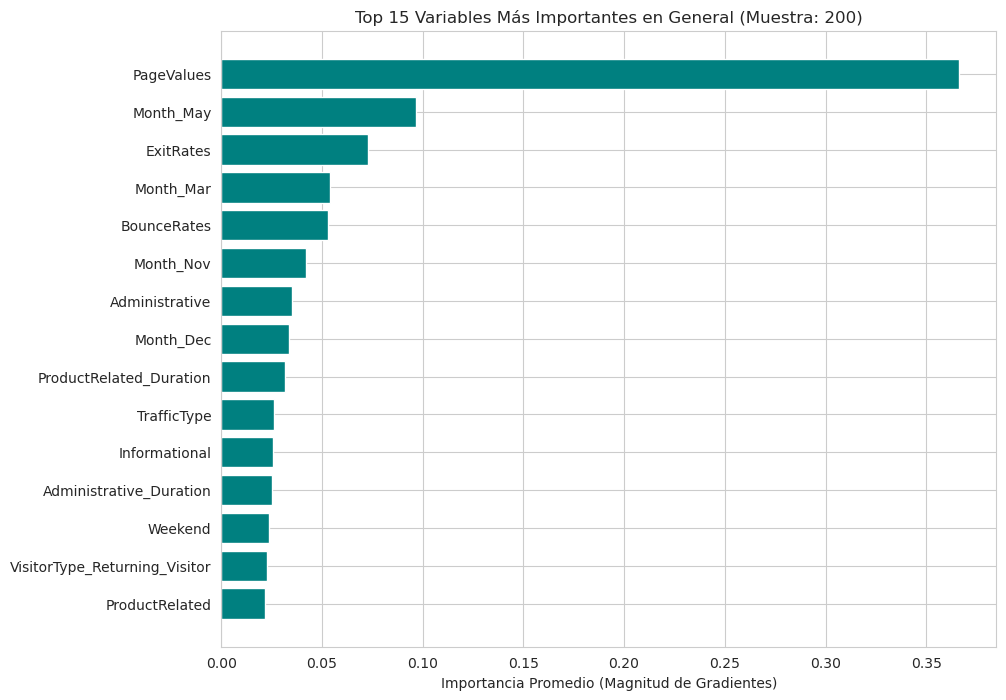

,Feature,Abs_Importance
4,ProductRelated,0.021833
25,VisitorType_Returning_Visitor,0.022909
14,Weekend,0.023768
1,Administrative_Duration,0.025168
2,Informational,0.025618
13,TrafficType,0.026413
5,ProductRelated_Duration,0.031498
15,Month_Dec,0.033793
0,Administrative,0.035220
21,Month_Nov,0.041851


In [35]:
analizar_importancia_global(model, X_test_tensor, X.columns, sample_size=200)

### Exportar modelo y artefactos

In [36]:
import json
import pickle

# Guardar modelo en formato Keras
model_path = os.path.join(models_dir, 'shoppers_nn_model.h5')
model.save(model_path)
print(f"Modelo guardado: {model_path}")

# Guardar scaler
scaler_path = os.path.join(models_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler guardado: {scaler_path}")

# Guardar nombres de features
features_path = os.path.join(models_dir, 'feature_names.json')
with open(features_path, 'w') as f:
    json.dump(list(X.columns), f, indent=2)
print(f"Features guardadas: {features_path}")

# Guardar parámetros del modelo
params_path = os.path.join(models_dir, 'model_params.json')
with open(params_path, 'w') as f:
    # Convertir valores no serializables
    params_to_save = model_params.copy()
    params_to_save["layers"] = [int(x) for x in params_to_save["layers"]]
    json.dump(params_to_save, f, indent=2)
print(f"Parámetros guardados: {params_path}")

# Loggear en MLflow
archivos_exportados = [model_path, scaler_path, features_path, params_path]
with mlflow.start_run(run_id=run.info.run_id):
    for archivo in archivos_exportados:
        mlflow.log_artifact(archivo, "exported_models")
    print(f"\n{len(archivos_exportados)} archivos registrados en MLflow")

Modelo guardado: ../exportaciones/nn-shoppers-gi/models/shoppers_nn_model.h5
Scaler guardado: ../exportaciones/nn-shoppers-gi/models/scaler.pkl
Features guardadas: ../exportaciones/nn-shoppers-gi/models/feature_names.json
Parámetros guardados: ../exportaciones/nn-shoppers-gi/models/model_params.json

4 archivos registrados en MLflow


/home/felipep/anaconda3/envs/dsml/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### Resumen del experimento MLflow

In [37]:
# Resumen del experimento
print("RESUMEN DEL EXPERIMENTO - Neural Network con Integrated Gradients")
print(f"Run ID: {run.info.run_id}")
print(f"Experimento: NN-Shoppers-IntegratedGradients")
print(f"Estado: {run.info.status}")
print(f"\nMétricas de entrenamiento:")
print(f"  - Train Accuracy: {final_train_acc:.4f}")
print(f"  - Validation Accuracy: {final_val_acc:.4f}")
print(f"\nMétricas de test:")
print(f"  - Test Accuracy: {test_accuracy:.4f}")
print(f"  - Test Precision: {test_precision:.4f}")
print(f"  - Test Recall: {test_recall:.4f}")
print(f"  - Test F1-Score: {test_f1:.4f}")
print(f"  - Test AUC: {test_auc:.4f}")

RESUMEN DEL EXPERIMENTO - Neural Network con Integrated Gradients
Run ID: e78b2e761fed4aa6af6a8126ff8e8de6
Experimento: NN-Shoppers-IntegratedGradients
Estado: RUNNING

Métricas de entrenamiento:
  - Train Accuracy: 0.8468
  - Validation Accuracy: 0.8771

Métricas de test:
  - Test Accuracy: 0.8869
  - Test Precision: 0.6039
  - Test Recall: 0.6906
  - Test F1-Score: 0.6443
  - Test AUC: 0.9221


## **Resultados**

#### Desempeño del Modelo

Tras entrenar la Red Neuronal Densa abordando el desbalanceo de clases mediante class_weights (pesando la clase minoritaria ~3.15 veces más ), y ajustando el umbral de decisión a 0.7, obtuvimos los siguientes resultados:

* Accuracy Global: 88%. El modelo acierta en la gran mayoría de los casos.
* Recall (Sensibilidad) para Compras: 74%. De todos los clientes que realmente compraron, el modelo fue capaz de detectar correctamente a casi 3 de cada 4. Esto es un logro significativo dado que originalmente solo representan el 15% del dataset.
* Precision para Compras: 59%. Cuando el modelo predice que alguien comprará, acierta el 59% de las veces. Al subir el umbral de 0.5 a 0.7, logramos reducir falsos positivos, haciendo las predicciones más confiables.

#### Análisis de Importancia (Global vs. Local)

Gracias a la técnica de Gradients Integrados, descubrimos patrones claros:

1. A Nivel Global: Al analizar una muestra de 200 clientes, la variable PageValues (valor promedio de las páginas visitadas) es, por lejos, el predictor más potente. Le siguen la estacionalidad (Month_May, Month_Nov) y las tasas de rebote (BounceRates).

2. A Nivel Local:
* En el Cliente #1 (Comprador), el modelo basó su decisión casi exclusivamente en un alto PageValues y en que la visita fue en Noviembre (Month_Nov), lo cual compensó factores negativos como Month_Oct .
* En el Cliente #100 (No Comprador), el modelo penalizó fuertemente el BounceRates (Tasa de Rebote alta) y el hecho de visitar en Mayo (Month_May), llevándolo a predecir correctamente la "No Compra".

## **Explicación de Predicciones con Gradients Integrados**

#### ¿Qué son los Gradients Integrados?

Las redes neuronales profundas suelen comportarse como "cajas negras": sabemos qué entra y qué sale, pero es difícil entender por qué toman ciertas decisiones. Para solucionar esto, utilizamos Integrated Gradients (IG), un método de atribución axiomática que asigna una puntuación de importancia a cada característica de entrada (*feature*) basándose en cuánto contribuyó a la predicción final.

#### ¿Cómo funciona?

La técnica se basa en calcular la integral de los gradientes de la salida del modelo con respecto a la entrada, a lo largo de un camino lineal. El proceso implementado en este trabajo sigue estos pasos:

1. Línea Base (Baseline): Definimos un punto de partida "neutral", en nuestro caso un vector de ceros (tf.zeros_like), que representa la ausencia de información (como una imagen en negro o un cliente "vacío").

2. Interpolación: Generamos una serie de pasos intermedios (alphas) que van gradualmente desde la *Línea Base* hasta el dato del *Cliente Real*. Es como usar un "dimmer" de luz que va subiendo la intensidad de las variables poco a poco.

3. Cálculo de Gradientes: Para cada paso interpolado, calculamos los gradientes de la predicción. Esto nos dice: *"En este punto exacto de intensidad, ¿cuánto cambia la probabilidad de compra si aumentamos ligeramente esta variable?"*.

4. Integración (Promedio): Promediamos todos los gradientes calculados a lo largo del camino y los multiplicamos por la diferencia entre la entrada real y la línea base. Esto nos da la atribución final.

El resultado nos indica no solo qué variables importan (magnitud), sino cómo afectan (signo):

* Valor Positivo (Verde): La variable empujó al modelo hacia la predicción de "COMPRA".
* Valor Negativo (Rojo): La variable empujó al modelo hacia "NO COMPRA".

## **Conclusiones**

1. Efectividad ante el Desbalanceo: Se demostró que es posible entrenar una red neuronal efectiva en un dataset altamente desbalanceado (85/15) sin necesidad de crear datos sintéticos (como con la librería SMOTE), utilizando simplemente una estrategia de ponderación de clases (class_weights). Esto permitió mantener un Recall alto (74%) sin sacrificar excesivamente la precisión.
2. Transparencia del Modelo: La implementación de Gradients Integrados transformó un modelo de "caja negra" en una herramienta explicable. Esto es crucial para el negocio, ya que permite confiar en las predicciones al validar que el modelo sigue una lógica coherente (ej. valorar más a usuarios que visitan páginas de alto valor).
3. Insights de Negocio:
    * El contenido es rey: La predominancia de PageValues sugiere que la calidad del contenido y las páginas de producto son determinantes para la conversión.
    * Factor Temporal: La influencia de meses específicos (Noviembre positivo, Mayo a veces negativo) indica una fuerte estacionalidad que debe ser aprovechada en campañas de marketing.
    * Señales de Alerta: Una alta Tasa de Rebote (BounceRates) es el indicador más claro de un cliente que no comprará, actuando como un "freno" fuerte en la red neuronal.